

| **모델 / 프레임워크**                         | **Supervision 변환 코드**                      |
| -------------------------------------- | ------------------------------------------ |
| **Ultralytics (YOLOv8, YOLO26 등)**     | `sv.Detections.from_ultralytics(results)`  |
| **Transformers (HuggingFace, DINO 등)** | `sv.Detections.from_transformers(results)` |
| **MMDetection**                        | `sv.Detections.from_mmdetection(results)`  |
| **Detectron2**                         | `sv.Detections.from_detectron2(results)`   |
| **SAM (Segment Anything)**             | `sv.Detections.from_sam(results)`          |




# Supervision 실습 노트북 (Colab)

Roboflow `supervision` 라이브러리의 핵심 기능 6가지를 순서대로 실습합니다.

1. 다양한 시각화 어노테이터 (Annotators)
2. 구역(Zone) / 선(Line) 기반 카운팅
3. 다중 객체 추적 (ByteTrack)
4. 후처리 & 필터링 (NMS / IoU / 조건 필터)
5. 데이터셋 관리 및 포맷 변환 (COCO / YOLO / VOC)
6. 비디오 처리 헬퍼 (Generator / VideoSink / process_video)

> **런타임 → 런타임 유형 변경 → GPU (T4)** 로 설정하면 훨씬 빠릅니다.

## 0. 설치 & 공통 준비

In [1]:
!pip install -q supervision ultralytics

import supervision as sv
print("supervision:", sv.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.7/405.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 6.5 MB/s eta 0:00:00
supervision: 0.30.8


In [2]:
import os
import cv2
import numpy as np
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
from supervision.assets import download_assets, VideoAssets

# 탐지 모델 / 세그멘테이션 모델 (nano 버전 - 가볍고 빠름)
model = YOLO("yolov8n.pt")
seg_model = YOLO("yolov8n-seg.pt")

# 샘플 영상 다운로드 (사람들이 걸어다니는 탑뷰 영상)
VIDEO_PATH = download_assets(VideoAssets.PEOPLE_WALKING)

video_info = sv.VideoInfo.from_video_path(VIDEO_PATH)
print(VIDEO_PATH, video_info)

W, H = video_info.resolution_wh

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
[2026-10-07 05:12:27] [INFO] supervision.assets.downloader - Downloading people-walking.mp4 assets


  0%|          | 0/7606633 [00:00<?, ?it/s]

people-walking.mp4 VideoInfo(width=1920, height=1080, fps=25.0, total_frames=341)


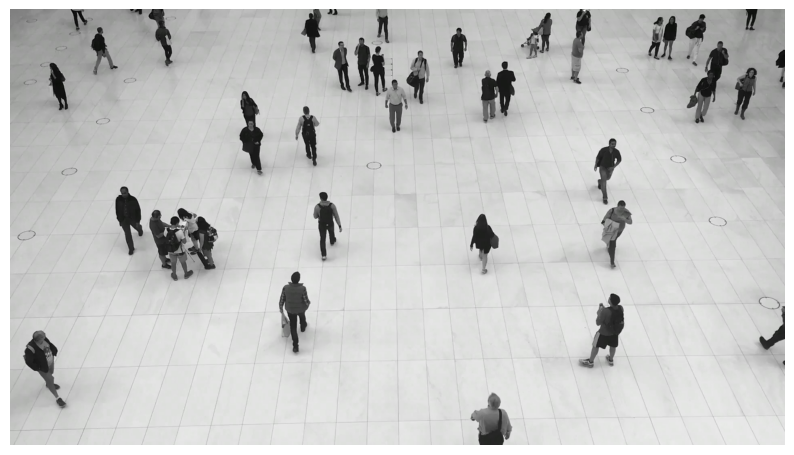

In [3]:
# 첫 프레임을 실습용 "이미지"로 사용
frame_generator = sv.get_video_frames_generator(VIDEO_PATH)
image = next(iter(frame_generator))

sv.plot_image(image, size=(10, 10))

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 코랩에서 결과 영상을 재생하기 위한 헬퍼
# (OpenCV가 만든 mp4v 코덱은 브라우저 재생이 안 되므로 H.264로 변환)
from IPython.display import HTML
from base64 import b64encode

def show_video(path, width=640):
    h264_path = path.replace(".mp4", "_h264.mp4")
    os.system(f"ffmpeg -y -loglevel error -i {path} -vcodec libx264 {h264_path}")
    data = b64encode(open(h264_path, "rb").read()).decode()
    return HTML(f'<video width={width} controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>')

---
## 1. 다양한 시각화 어노테이터 (Annotators)

모든 어노테이터는 `annotate(scene=이미지, detections=탐지결과)` 형태로 동일하게 사용합니다.
즉, **레고 블록처럼 겹쳐서(chaining) 쓸 수 있습니다.**

탐지 개수: 39


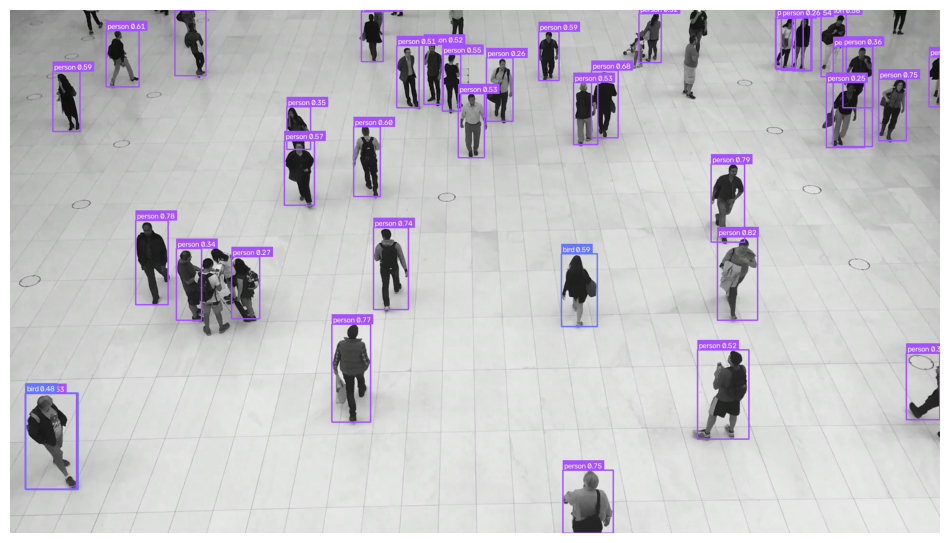

In [6]:
# 1-1. BoxAnnotator + LabelAnnotator : 경계 상자 + 클래스명/확률
result = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1, text_padding=3)

labels = [
    f"{name} {conf:.2f}"
    for name, conf in zip(detections["class_name"], detections.confidence)
]

annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

print("탐지 개수:", len(detections))
sv.plot_image(annotated, size=(12, 12))

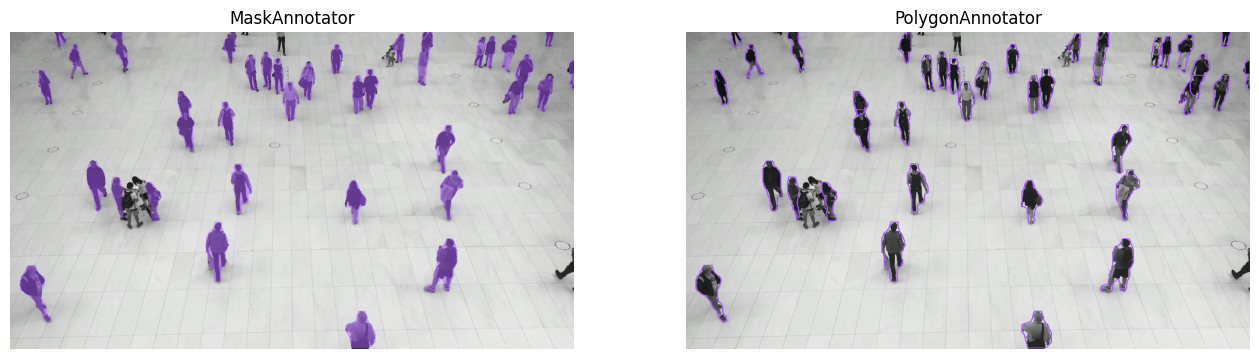

In [7]:
# 1-2. MaskAnnotator / PolygonAnnotator : 세그멘테이션 결과 시각화
seg_result = seg_model(image, verbose=False)[0]
seg_detections = sv.Detections.from_ultralytics(seg_result)

mask_annotator = sv.MaskAnnotator(opacity=0.5)
polygon_annotator = sv.PolygonAnnotator(thickness=2)

sv.plot_images_grid(
    images=[
        mask_annotator.annotate(image.copy(), seg_detections),
        polygon_annotator.annotate(image.copy(), seg_detections),
    ],
    grid_size=(1, 2),
    titles=["MaskAnnotator", "PolygonAnnotator"],
    size=(16, 8),
)

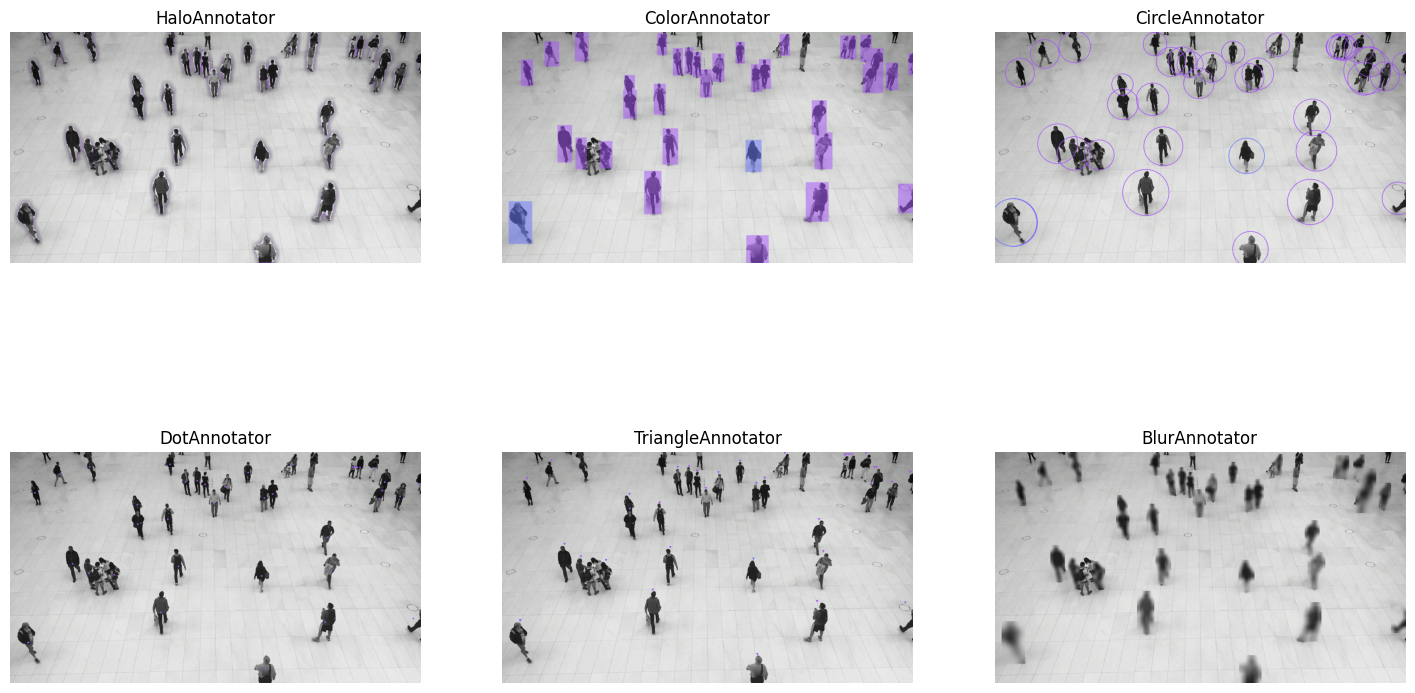

In [8]:
# 1-3. 그 외 스타일 어노테이터 한눈에 비교
# 주의: HaloAnnotator 는 mask 정보가 필요하므로 seg_detections 를 사용
gallery = {
    "HaloAnnotator":     (sv.HaloAnnotator(),     seg_detections),
    "ColorAnnotator":    (sv.ColorAnnotator(),    detections),
    "CircleAnnotator":   (sv.CircleAnnotator(),   detections),
    "DotAnnotator":      (sv.DotAnnotator(),      detections),
    "TriangleAnnotator": (sv.TriangleAnnotator(), detections),
    "BlurAnnotator":     (sv.BlurAnnotator(),     detections),
}

images, titles = [], []
for name, (annotator, dets) in gallery.items():
    images.append(annotator.annotate(image.copy(), dets))
    titles.append(name)

sv.plot_images_grid(images, grid_size=(2, 3), titles=titles, size=(18, 10))

/tmp/ipykernel_1112/272298819.py:7: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack(frame_rate=video_info.fps)
100%|██████████| 200/200 [00:49<00:00,  4.05it/s]


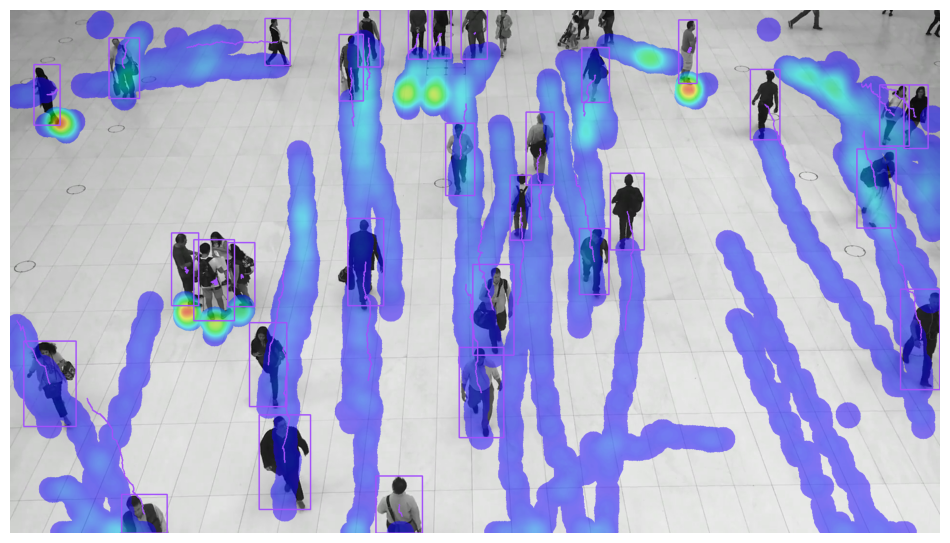

In [9]:
# 1-4. TraceAnnotator / HeatMapAnnotator
# 두 어노테이터는 "시간의 흐름"이 필요하므로 영상 프레임을 순회하며 사용합니다.
# TraceAnnotator 는 tracker_id 가 필수 -> ByteTrack 을 먼저 통과시킵니다.
N_FRAMES = 200
TRACE_VIDEO = "01_trace_heatmap.mp4"

tracker = sv.ByteTrack(frame_rate=video_info.fps)
trace_annotator = sv.TraceAnnotator(trace_length=60, thickness=2)
heatmap_annotator = sv.HeatMapAnnotator(opacity=0.5, radius=25, kernel_size=25)

last_frame = None
with sv.VideoSink(target_path=TRACE_VIDEO, video_info=video_info) as sink:
    for frame in tqdm(sv.get_video_frames_generator(VIDEO_PATH, end=N_FRAMES), total=N_FRAMES):
        det = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
        det = tracker.update_with_detections(det)

        out = heatmap_annotator.annotate(scene=frame.copy(), detections=det)   # 히트맵(누적)
        out = trace_annotator.annotate(scene=out, detections=det)              # 이동 궤적
        out = box_annotator.annotate(scene=out, detections=det)

        sink.write_frame(out)
        last_frame = out

sv.plot_image(last_frame, size=(12, 12))   # 마지막 프레임 = 누적 히트맵이 가장 진한 상태

In [ ]:
show_video(TRACE_VIDEO)

---
## 2. 구역(Zone) 및 선(Line) 기반 카운팅

전체 39개 중 구역 내부 4개


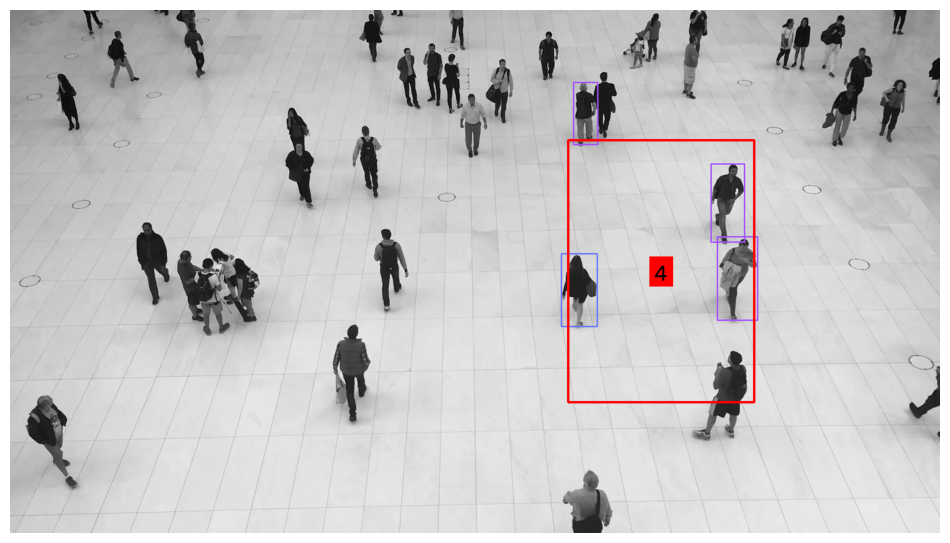

In [10]:
# 2-1. PolygonZone : 다각형 구역 안의 객체만 필터링/카운팅
polygon = np.array([
    [W * 0.60, H * 0.25],
    [W * 0.80, H * 0.25],
    [W * 0.80, H * 0.75],
    [W * 0.60, H * 0.75],
]).astype(int)

# supervision 0.24+ 는 polygon 만 받습니다 (구버전 호환용 예외처리)
try:
    zone = sv.PolygonZone(polygon=polygon)
except TypeError:
    zone = sv.PolygonZone(polygon=polygon, frame_resolution_wh=video_info.resolution_wh)

mask = zone.trigger(detections=detections)   # 구역 안이면 True 인 bool 배열
detections_in_zone = detections[mask]

print(f"전체 {len(detections)}개 중 구역 내부 {len(detections_in_zone)}개")

zone_annotator = sv.PolygonZoneAnnotator(zone=zone, color=sv.Color.RED, thickness=4, text_scale=1.5)

annotated = box_annotator.annotate(image.copy(), detections_in_zone)
annotated = zone_annotator.annotate(scene=annotated)
sv.plot_image(annotated, size=(12, 12))

100%|██████████| 200/200 [00:35<00:00,  5.58it/s]


IN: 5 / OUT: 5


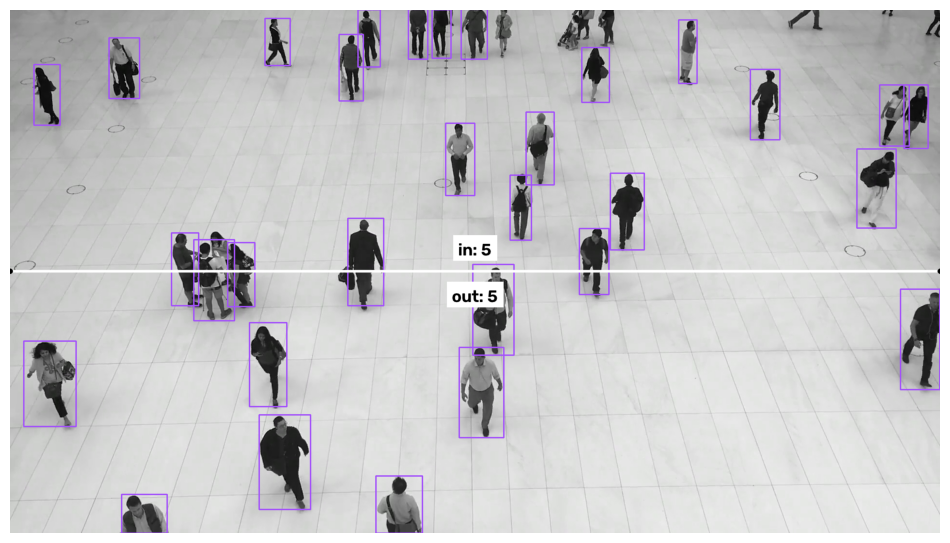

In [11]:
# 2-2. LineZone : 가상의 선을 넘나드는 객체 수를 실시간 집계 (in / out)
LINE_VIDEO = "02_line_counting.mp4"
N_FRAMES = 200

line_zone = sv.LineZone(start=sv.Point(0, H // 2), end=sv.Point(W, H // 2))
line_annotator = sv.LineZoneAnnotator(thickness=3, text_thickness=2, text_scale=1.2)

tracker = sv.ByteTrack(frame_rate=video_info.fps)   # LineZone 은 tracker_id 필수

last_frame = None
with sv.VideoSink(target_path=LINE_VIDEO, video_info=video_info) as sink:
    for frame in tqdm(sv.get_video_frames_generator(VIDEO_PATH, end=N_FRAMES), total=N_FRAMES):
        det = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
        det = tracker.update_with_detections(det)

        line_zone.trigger(detections=det)   # 내부 카운터 갱신

        out = box_annotator.annotate(frame.copy(), det)
        out = line_annotator.annotate(frame=out, line_counter=line_zone)
        sink.write_frame(out)
        last_frame = out

print(f"IN: {line_zone.in_count} / OUT: {line_zone.out_count}")
sv.plot_image(last_frame, size=(12, 12))

In [ ]:
show_video(LINE_VIDEO)

---
## 3. 다중 객체 추적 (Multi-Object Tracking, ByteTrack)

`tracker.update_with_detections(detections)` 한 줄이면 `detections.tracker_id` 가 채워집니다.
같은 사람이면 프레임이 바뀌어도 동일한 ID가 유지됩니다.

100%|██████████| 200/200 [00:37<00:00,  5.38it/s]


200 프레임 동안 등장한 고유 객체 수: 71


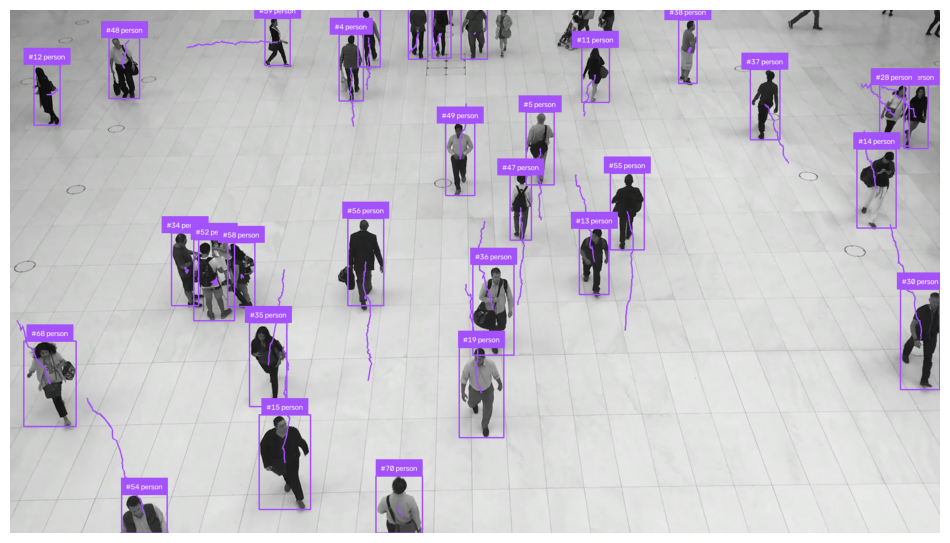

In [12]:
TRACK_VIDEO = "03_tracking.mp4"
N_FRAMES = 200

tracker = sv.ByteTrack(frame_rate=video_info.fps)
trace_annotator = sv.TraceAnnotator(trace_length=60)
track_label_annotator = sv.LabelAnnotator(text_scale=0.5, text_position=sv.Position.TOP_CENTER)

id_history = set()
last_frame = None

with sv.VideoSink(target_path=TRACK_VIDEO, video_info=video_info) as sink:
    for frame in tqdm(sv.get_video_frames_generator(VIDEO_PATH, end=N_FRAMES), total=N_FRAMES):
        det = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
        det = tracker.update_with_detections(det)

        id_history.update(det.tracker_id.tolist())

        labels = [f"#{tid} {name}" for tid, name in zip(det.tracker_id, det["class_name"])]

        out = box_annotator.annotate(frame.copy(), det)
        out = trace_annotator.annotate(out, det)
        out = track_label_annotator.annotate(out, det, labels=labels)
        sink.write_frame(out)
        last_frame = out

print(f"{N_FRAMES} 프레임 동안 등장한 고유 객체 수: {len(id_history)}")
sv.plot_image(last_frame, size=(12, 12))

In [ ]:
show_video(TRACK_VIDEO)

---
## 4. 후처리 및 필터링 (Post-Processing)

NMS 이전: 244 -> 이후: 51 (class-agnostic: 49)


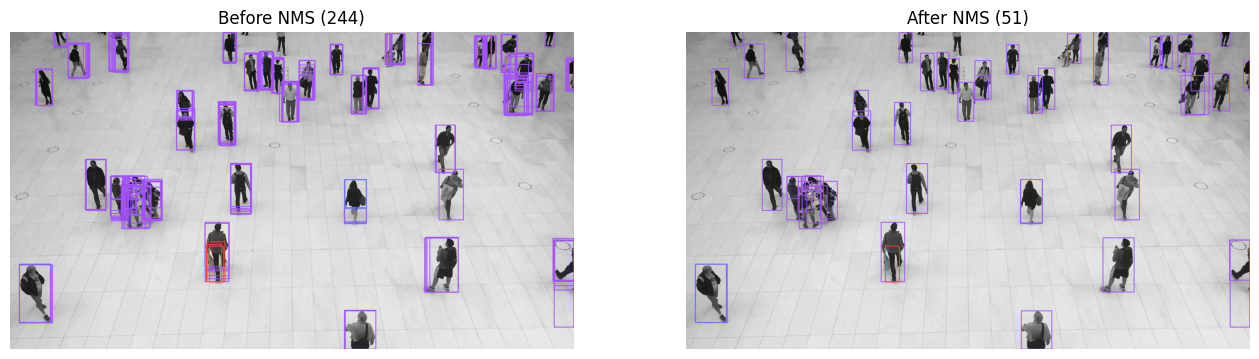

In [13]:
# 4-1. NMS (Non-Maximum Suppression)
# 일부러 conf 를 낮추고 iou 를 높여서 "중복 박스가 많은" 상태를 만든 뒤 정리해봅니다.
raw_result = model(image, conf=0.05, iou=0.95, verbose=False)[0]
raw_detections = sv.Detections.from_ultralytics(raw_result)

nms_detections = raw_detections.with_nms(threshold=0.5)            # 클래스 무관 X, 기본은 클래스별
agnostic     = raw_detections.with_nms(threshold=0.5, class_agnostic=True)

print(f"NMS 이전: {len(raw_detections)} -> 이후: {len(nms_detections)} (class-agnostic: {len(agnostic)})")

sv.plot_images_grid(
    images=[
        box_annotator.annotate(image.copy(), raw_detections),
        box_annotator.annotate(image.copy(), nms_detections),
    ],
    grid_size=(1, 2),
    titles=[f"Before NMS ({len(raw_detections)})", f"After NMS ({len(nms_detections)})"],
    size=(16, 8),
)

In [14]:
# 4-2. IoU 계산 : 두 박스 집합 간의 겹침 정도를 행렬로 반환
boxes_a = detections.xyxy[:3]
boxes_b = detections.xyxy[:3]

iou_matrix = sv.box_iou_batch(boxes_a, boxes_b)
print("IoU matrix (3x3):")
print(np.round(iou_matrix, 3))

IoU matrix (3x3):
[[          1       0.024           0]
 [      0.024           1           0]
 [          0           0           1]]


In [15]:
# 4-3. 조건별 필터링 : numpy 불리언 인덱싱과 완전히 동일한 문법
high_conf = detections[detections.confidence > 0.7]                  # 신뢰도
persons   = detections[detections.class_id == 0]                     # 클래스 ID
by_name   = detections[np.isin(detections["class_name"], ["person"])] # 클래스 이름
in_zone   = detections[zone.trigger(detections)]                     # 구역 내부
big_boxes = detections[detections.area > 5000]                       # 박스 넓이

combined  = detections[(detections.confidence > 0.5) & (detections.class_id == 0)]  # 복합 조건

for label, d in [("전체", detections), ("conf>0.7", high_conf), ("person", persons),
                 ("구역 내부", in_zone), ("area>5000", big_boxes), ("복합조건", combined)]:
    print(f"{label:>10} : {len(d)}개")

        전체 : 39개
  conf>0.7 : 7개
    person : 37개
     구역 내부 : 4개
 area>5000 : 30개
      복합조건 : 22개


---
## 5. 데이터셋 관리 및 포맷 변환

실습용 데이터셋이 없으므로, **영상에서 프레임을 뽑고 모델 예측을 라벨처럼 사용해서**
미니 데이터셋을 직접 만든 뒤 포맷 변환을 실습합니다.

In [ ]:
# 5-1. 미니 데이터셋 생성 (프레임 10장 + 예측 결과를 어노테이션으로 사용)
os.makedirs("mini_dataset/images", exist_ok=True)

image_paths, annotations = [], {}

for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH, stride=30, end=300)):
    path = f"mini_dataset/images/frame_{i:03d}.jpg"
    cv2.imwrite(path, frame)

    det = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
    image_paths.append(path)
    annotations[path] = det

dataset = sv.DetectionDataset(
    classes=list(model.names.values()),   # COCO 80 클래스
    images=image_paths,
    annotations=annotations,
)

print(f"이미지 {len(dataset)}장, 클래스 {len(dataset.classes)}개")

이미지 10장, 클래스 80개


In [ ]:
# 5-2. 포맷 상호 변환 : YOLO / COCO / Pascal VOC 로 저장/// 3대 표준 데이터셋 포맷
dataset.as_yolo(
    images_directory_path="export_yolo/images",
    annotations_directory_path="export_yolo/labels",
    data_yaml_path="export_yolo/data.yaml",
)

dataset.as_coco(
    images_directory_path="export_coco/images",
    annotations_path="export_coco/annotations.json",
)

dataset.as_pascal_voc(
    images_directory_path="export_voc/images",
    annotations_directory_path="export_voc/annotations",
)


In [ ]:
# 5-3. 다시 불러오기 (COCO -> Detections) + 분할 + 병합
loaded = sv.DetectionDataset.from_coco(
    images_directory_path="export_coco/images",
    annotations_path="export_coco/annotations.json",
)
print("불러온 이미지 수:", len(loaded))

train, val = loaded.split(split_ratio=0.7, random_state=42, shuffle=True)
print(f"train: {len(train)} / val: {len(val)}")

merged = sv.DetectionDataset.merge([train, val])
print("merge 결과:", len(merged))

불러온 이미지 수: 10
train: 7 / val: 3
merge 결과: 10


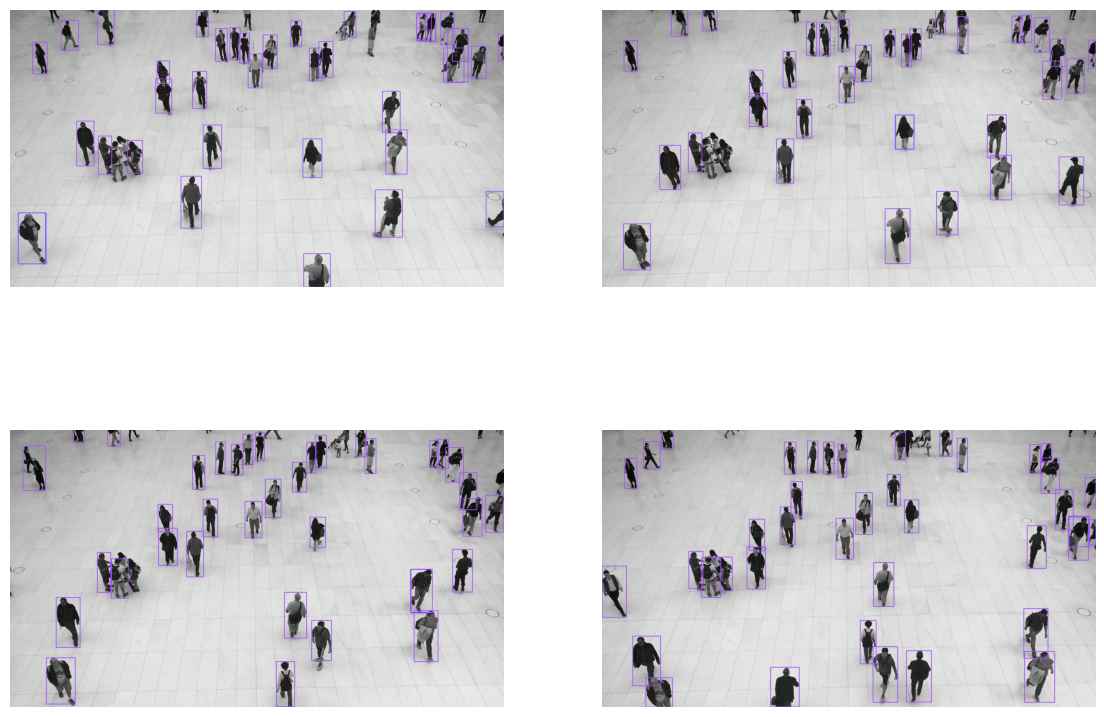

In [ ]:
# 5-4. 로드한 데이터셋 시각화로 검증
samples = []
for image_path, img, ann in list(loaded)[:4]:
    samples.append(box_annotator.annotate(img.copy(), ann))

sv.plot_images_grid(samples, grid_size=(2, 2), size=(14, 10))

---
## 6. 비디오 처리 헬퍼 (Video Utilities)

In [ ]:
# 6-1. VideoInfo : 영상 메타데이터 확인
info = sv.VideoInfo.from_video_path(VIDEO_PATH)
print(f"해상도: {info.resolution_wh}, FPS: {info.fps}, 총 프레임: {info.total_frames}")

해상도: (1920, 1080), FPS: 25.0, 총 프레임: 341


샘플링된 프레임 수: 3


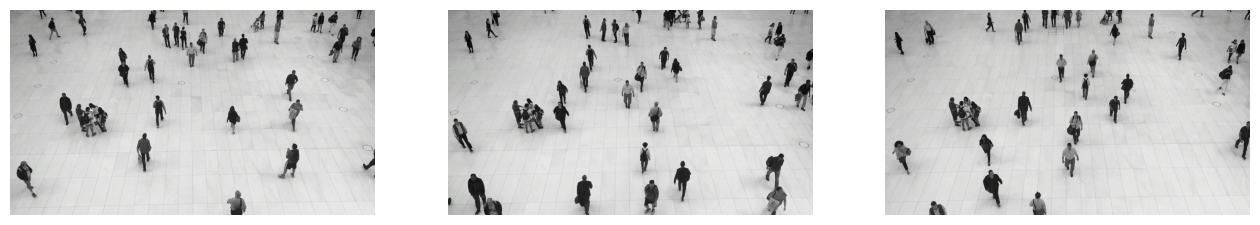

In [ ]:
# 6-2. get_video_frames_generator : 메모리에 다 올리지 않고 한 장씩 꺼내는 제너레이터
#      start / end / stride 로 원하는 구간만 샘플링 가능
frames = list(sv.get_video_frames_generator(VIDEO_PATH, start=0, end=300, stride=100))
print("샘플링된 프레임 수:", len(frames))

sv.plot_images_grid(frames, grid_size=(1, len(frames)), size=(16, 6))

In [ ]:
# 6-3. VideoSink : 처리한 프레임을 영상 파일로 저장 (짧은 클립 만들기)
CLIP_PATH = "04_short_clip.mp4"

with sv.VideoSink(target_path=CLIP_PATH, video_info=video_info) as sink:
    for frame in sv.get_video_frames_generator(VIDEO_PATH, end=300,stride=10):
        sink.write_frame(frame)

print("저장 완료:", CLIP_PATH)
show_video(CLIP_PATH)

저장 완료: 04_short_clip.mp4


In [ ]:
# 6-4. process_video : 위 generator + sink 반복문을 한 줄로 압축해주는 헬퍼
PROCESSED_PATH = "05_processed.mp4"

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    det = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
    labels = [f"{n} {c:.2f}" for n, c in zip(det["class_name"], det.confidence)]
    out = box_annotator.annotate(frame.copy(), det)
    return label_annotator.annotate(out, det, labels=labels)

sv.process_video(
    source_path=CLIP_PATH,        # 짧은 클립에만 적용 (원본 전체는 오래 걸림)
    target_path=PROCESSED_PATH,
    callback=callback,
)

show_video(PROCESSED_PATH)

---
## 정리

| 기능 | 핵심 API |
|---|---|
| 시각화 | `sv.BoxAnnotator`, `LabelAnnotator`, `MaskAnnotator`, `PolygonAnnotator`, `TraceAnnotator`, `HeatMapAnnotator`, `HaloAnnotator` … |
| 구역/선 카운팅 | `sv.PolygonZone` + `PolygonZoneAnnotator`, `sv.LineZone` + `LineZoneAnnotator` |
| 추적 | `sv.ByteTrack().update_with_detections()` |
| 후처리 | `detections.with_nms()`, `sv.box_iou_batch()`, 불리언 인덱싱 |
| 데이터셋 | `sv.DetectionDataset.from_/as_ (yolo·coco·pascal_voc)`, `.split()`, `.merge()` |
| 비디오 | `sv.get_video_frames_generator`, `sv.VideoSink`, `sv.process_video`, `sv.VideoInfo` |

핵심은 **모든 모델 출력을 `sv.Detections` 하나로 통일**한다는 점입니다.
`from_ultralytics` 대신 `from_inference`, `from_transformers`, `from_sam` 등으로 바꾸면
아래 코드는 그대로 두고 모델만 교체할 수 있습니다.